In [65]:
import sys
sys.path.append('../')

import warnings
warnings.filterwarnings("ignore")

from utils import *
from tqdm.auto import tqdm
import numpy as np
import pickle
import os

import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100,
                     "grid.alpha" : 0.3,
                     "axes.grid": False,
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16,
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

from experiment import unpack_and_dequantize

In [84]:
REGIMES = {
    "high_welfare":  {"alpha": 0.3, "gamma": 0.8,  "label": r"High Welfare ($\alpha=0.3$, $\gamma=0.8$)"},
    "transition":    {"alpha": 0.65, "gamma": 0.6,  "label": r"Oscillating ($\alpha=0.65$, $\gamma=0.6$)"},
    "low_welfare":   {"alpha": 0.7, "gamma": 0.2,  "label": r"Low Welfare ($\alpha=0.7$, $\gamma=0.2$)"},
}

p_values = np.linspace(0.05, 0.95, 15)

# --- Collect data for all regimes ---
regime_data = {}

for regime_name, regime_params in REGIMES.items():
    alpha = regime_params["alpha"]
    data_dir = f"../data/probability_sweep/{regime_name}/raw"

    p_increases = []
    p_decreases = []
    welfare_values = []

    for fname in os.listdir(data_dir):
        if not fname.endswith(".pickle"):
            continue
        try:
            parts = fname.replace(".pickle", "").split("_")
            p_inc = float(parts[0])
            p_dec = float(parts[1])

            if not (np.isclose(p_values, p_inc).any() and np.isclose(p_values, p_dec).any()):
                continue

            with open(os.path.join(data_dir, fname), "rb") as f:
                data = pickle.load(f)

            wel = sen_welfare(
                utility(
                    unpack_and_dequantize(data["wealth"][:, -1], 200),
                    unpack_and_dequantize(data["health"][:, -1], 200),
                    alpha=alpha
                )
            )

            p_increases.append(p_inc)
            p_decreases.append(p_dec)
            welfare_values.append(wel)

        except (ValueError, KeyError):
            continue

    regime_data[regime_name] = {
        "p_increases": np.array(p_increases),
        "p_decreases": np.array(p_decreases),
        "welfare_values": np.array(welfare_values),
    }


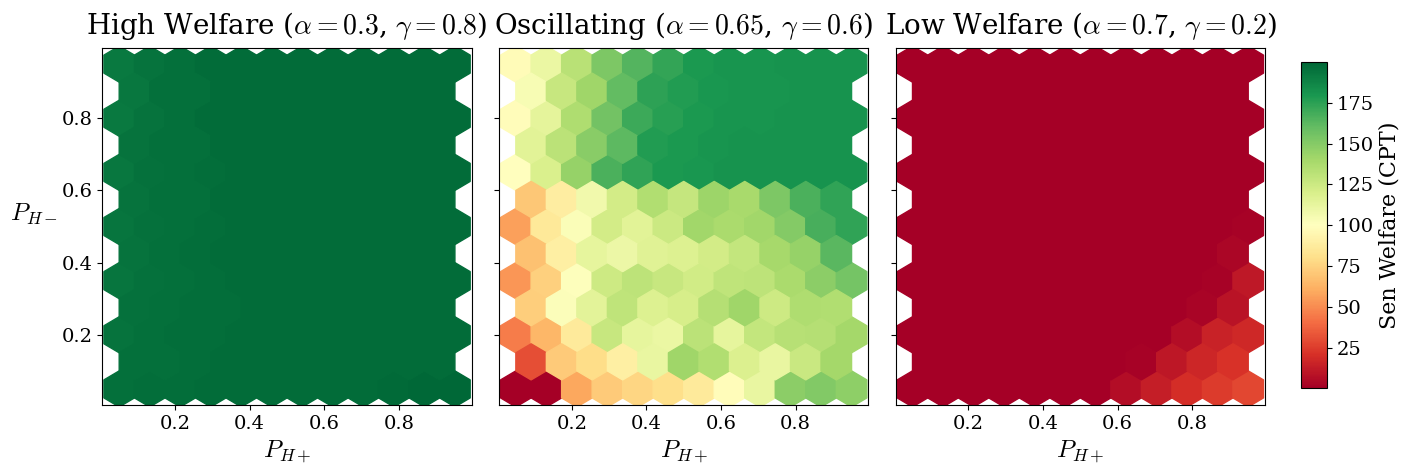

In [85]:
# --- Determine shared colour scale across all three regimes ---
all_welfare = np.concatenate([regime_data[r]["welfare_values"] for r in REGIMES])
vmin = all_welfare.min()
vmax = all_welfare.max()

# --- Plot ---
fig, axs = plt.subplots(1, 3, figsize=(13, 5), sharey=True)

grid_size = 11

for ax, (regime_name, regime_params) in zip(axs, REGIMES.items()):
    d = regime_data[regime_name]

    hb = ax.hexbin(
        d["p_increases"], d["p_decreases"],
        C=d["welfare_values"],
        gridsize=grid_size,
        cmap="RdYlGn",
        vmin=vmin, vmax=vmax,
        reduce_C_function=np.mean,
        mincnt=1
    )

    ax.set_title(regime_params["label"], fontsize=20, pad=10)
    ax.set_xlabel(r"$P_{H+}$", fontsize=18)

axs[0].set_ylabel(r"$P_{H-}$", rotation=0, labelpad=20, fontsize=18)

# Shared colourbar on the right
# Add colourbar in its own space to the right of the subplots
cbar_ax = fig.add_axes([1.01, 0.2, 0.02, 0.65])  # [left, bottom, width, height]
fig.colorbar(hb, cax=cbar_ax, label="Sen Welfare (CPT)")

fig.tight_layout()
plt.savefig("../figures/probability_sweep.pdf", bbox_inches="tight")
plt.show()

In [87]:
REGIMES = {
    "high_welfare": {"alpha": 0.3, "gamma": 0.8, "label": r"High Welfare ($\alpha=0.3$, $\gamma=0.8$)", "color": "#2ca02c"},
    "transition":   {"alpha": 0.65, "gamma": 0.6, "label": r"Oscillating ($\alpha=0.65$, $\gamma=0.6$)",   "color": "#ff7f0e"},
    "low_welfare":  {"alpha": 0.7, "gamma": 0.2, "label": r"Low Welfare ($\alpha=0.7$, $\gamma=0.2$)",  "color": "#d62728"},
}

p_values = np.round(np.linspace(0.05, 0.95, 15), 4)

P_H_PLUS_FIXED  = p_values[np.argmin(np.abs(p_values - 0.95))]
P_H_MINUS_FIXED = p_values[np.argmin(np.abs(p_values - 0.05))]

# --- Collect data ---
regime_data = {}

for regime_name, regime_params in REGIMES.items():
    alpha    = regime_params["alpha"]
    data_dir = f"../data/probability_sweep/{regime_name}/raw/"

    welfare_grid = np.full((len(p_values), len(p_values)), np.nan)
    policy_grid  = np.full((len(p_values), len(p_values)), np.nan)

    for fname in os.listdir(data_dir):
        if not fname.endswith(".pickle"):
            continue
        try:
            parts = fname.replace(".pickle", "").split("_")
            p_inc = round(float(parts[0]), 4)
            p_dec = round(float(parts[1]), 4)

            idx_inc = np.where(np.isclose(p_values, p_inc))[0]
            idx_dec = np.where(np.isclose(p_values, p_dec))[0]
            if len(idx_inc) == 0 or len(idx_dec) == 0:
                continue

            with open(os.path.join(data_dir, fname), "rb") as f:
                data = pickle.load(f)

            wel = sen_welfare(
                utility(
                    unpack_and_dequantize(data["wealth"][:, -1], 200),
                    unpack_and_dequantize(data["health"][:, -1], 200),
                    alpha=alpha
                )
            )

            welfare_grid[idx_dec[0], idx_inc[0]] = wel
            policy_grid[idx_dec[0], idx_inc[0]]  = data["policy"].mean()

        except (ValueError, KeyError, IndexError):
            continue

    regime_data[regime_name] = {
        "welfare_grid": welfare_grid,
        "policy_grid":  policy_grid,
    }

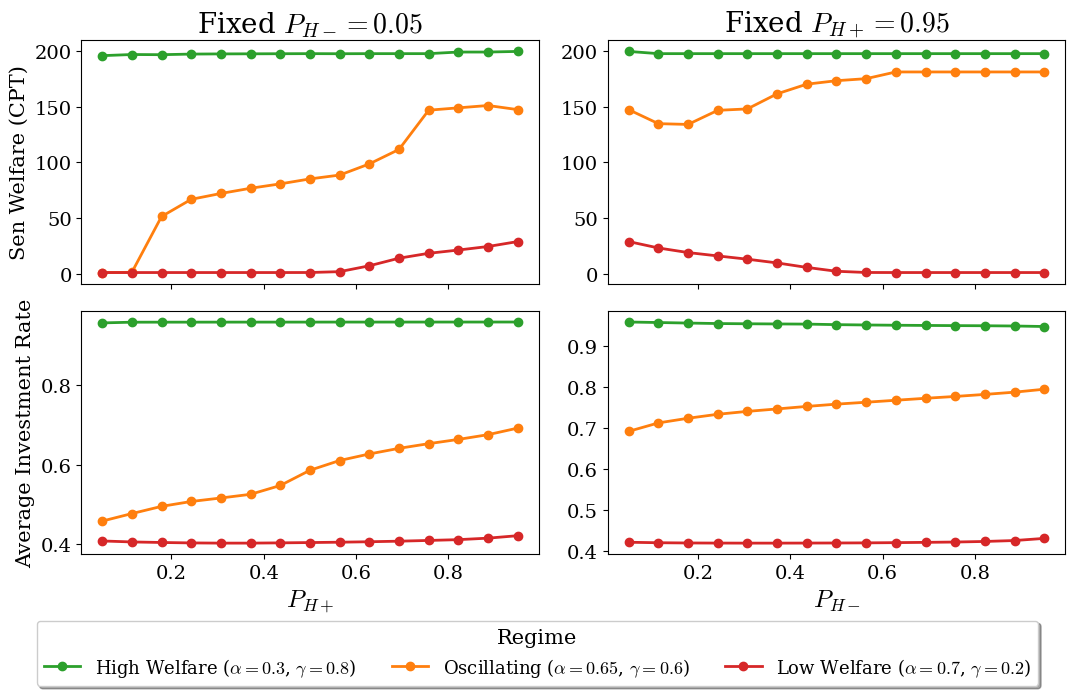

In [88]:
# --- Plot: two rows (welfare / investment rate), two cols (vary P_H+ / vary P_H-) ---
fig, axs = plt.subplots(2, 2, figsize=(11, 6.5), sharex="col")

idx_fixed_plus  = np.where(np.isclose(p_values, P_H_PLUS_FIXED))[0][0]
idx_fixed_minus = np.where(np.isclose(p_values, P_H_MINUS_FIXED))[0][0]

for regime_name, regime_params in REGIMES.items():
    color = regime_params["color"]
    label = regime_params["label"]
    wg    = regime_data[regime_name]["welfare_grid"]
    pg    = regime_data[regime_name]["policy_grid"]

    # Vary P_H+, fix P_H-
    axs[0, 0].plot(p_values, wg[idx_fixed_minus, :], marker="o", color=color, label=label, linewidth=2)
    axs[1, 0].plot(p_values, pg[idx_fixed_minus, :], marker="o", color=color, label=label, linewidth=2)

    # Vary P_H-, fix P_H+
    axs[0, 1].plot(p_values, wg[:, idx_fixed_plus], marker="o", color=color, label=label, linewidth=2)
    axs[1, 1].plot(p_values, pg[:, idx_fixed_plus], marker="o", color=color, label=label, linewidth=2)

# Titles and labels
axs[0, 0].set_title(rf"Fixed $P_{{H-}}={P_H_MINUS_FIXED:.2f}$", fontsize=20)
axs[0, 1].set_title(rf"Fixed $P_{{H+}}={P_H_PLUS_FIXED:.2f}$",  fontsize=20)

axs[0, 0].set_ylabel("Sen Welfare (CPT)", fontsize=15)
axs[1, 0].set_ylabel("Average Investment Rate", fontsize=15)

axs[1, 0].set_xlabel(r"$P_{H+}$", fontsize=18)
axs[1, 1].set_xlabel(r"$P_{H-}$", fontsize=18)

fig.tight_layout()
fig.legend(
    *axs[0, 0].get_legend_handles_labels(),
    loc="lower center",
    ncol=3,
    shadow=True,
    bbox_to_anchor=(0.5, -0.09),
    fontsize=13,
    title="Regime"
)

plt.savefig("../figures/probability_sweep_policy_check.pdf", bbox_inches="tight")
plt.show()